# AA-UTE 2026

## P4 - Forecasting con arboles y redes neuronales

Este practico se centra en el uso de modelos de forecasting basados en árboles y redes neuronales. Se trabajará sobre una serie de datos reales correspondiente a la demanda de energía eléctrica en la ciudad de Mercedes, Soriano.

Al finalizar este practico se espera que el estudiante haya podido experimentar con:

- construir features clásicas y targets para el entrenamiento de modelos de forecasating;
- implementar modelos de forecasting con RandomForest y XGBoost de la libreria `sklearn` y `xgboost`;
- implementar un modelo convolucional temporal (TCN) y compararlo con un modelo recurrente (RNN) para forecasting de la libreria `neuralforecast`;

### Trabajo a realizar

Este notebook esta pensado para que al principio se puedan correr las diferentes celdas tal y como están y analizar los resultados. Luego, se proponen algunas modificaciones para que el estudiante pueda experimentar con los modelos y analizar los resultados.

In [57]:
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

import xgboost as xgb

from neuralforecast import NeuralForecast
from neuralforecast.models import RNN, TCN
from neuralforecast.losses.pytorch import MSE

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (14, 4)

## Parte 1 - Serie base y extraccion de caracteristicas

Primero cargamos los datos.

In [58]:
# ---------------------------------------------------------------
# 1. Carga de datos
#   - Se cargan los datos que contiene la serie de tiempo a una frecuencia de 15 minutos.
#   - Se convierten los timestamps a formato datetime y se setea como índice del dataframe.
#   - Se remueven columnas innecesarias y se re-muestrea la serie a frecuencia horaria.  
# ---------------------------------------------------------------
path_file = "~/Downloads/DATOS_15MIN_MER_trainset-labeled.csv" # puede que sea necesario cambiar la ruta de este archivo.
dta = pd.read_csv(path_file, low_memory=False)
dta["timestamp"] = pd.to_datetime(dta["timestamp"])
dta.set_index("timestamp", inplace=True)
dta = dta[dta["series"] == "OFI"].copy()
dta = dta.drop(columns=["series", "label"])
dta = dta.resample("h").mean()

dta.head()

,value
timestamp,
2015-04-14 00:00:00+00:00,5.076925
2015-04-14 01:00:00+00:00,4.490550
2015-04-14 02:00:00+00:00,4.210925
2015-04-14 03:00:00+00:00,4.065475
2015-04-14 04:00:00+00:00,4.026950


In [59]:
print(dta.shape)
dta.tail()

(82537, 1)


,value
timestamp,
2024-09-11 20:00:00+00:00,-0.00375
2024-09-11 21:00:00+00:00,-0.00375
2024-09-11 22:00:00+00:00,-0.00375
2024-09-11 23:00:00+00:00,-0.00375
2024-09-12 00:00:00+00:00,-0.00400


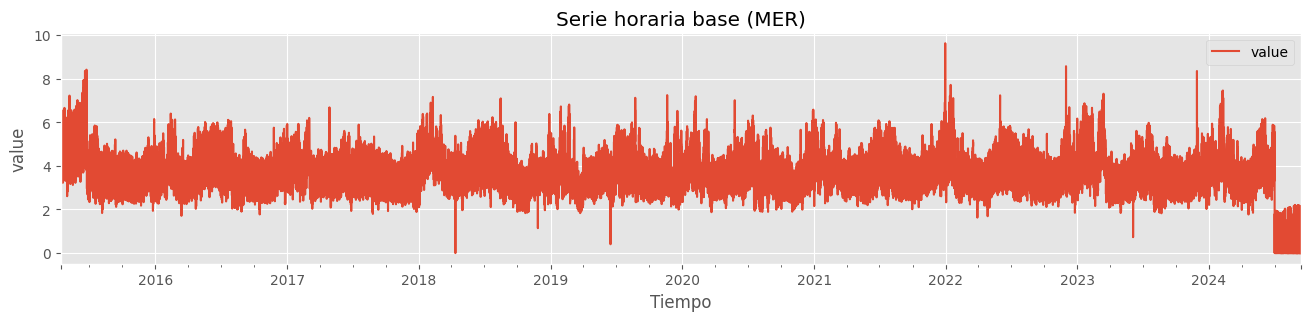

In [60]:
dta.plot(figsize=(16, 3), title="Serie horaria base (MER)")
plt.xlabel("Tiempo")
plt.ylabel("value")
plt.show()

### EXPERIMENTAR Y DISCUTIR

Visualizar los datos a otras escalas (anual, mensual, semanal), y discutir:

1. ¿Qué patrones se observan a simple vista?
2. ¿Aparecen valores atípicos?

**Respuestas**



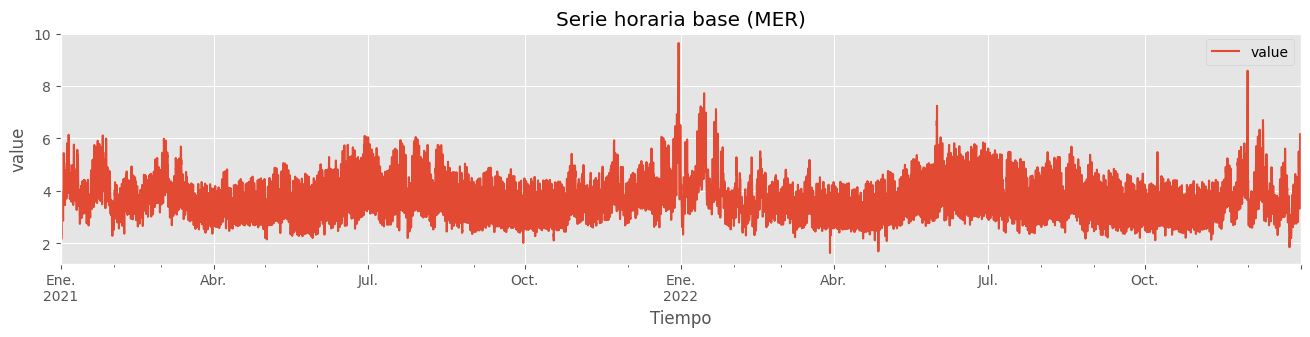

In [61]:
dta["2021":"2022"].plot(figsize=(16, 3), title="Serie horaria base (MER)")
plt.xlabel("Tiempo")
plt.ylabel("value")
plt.show()

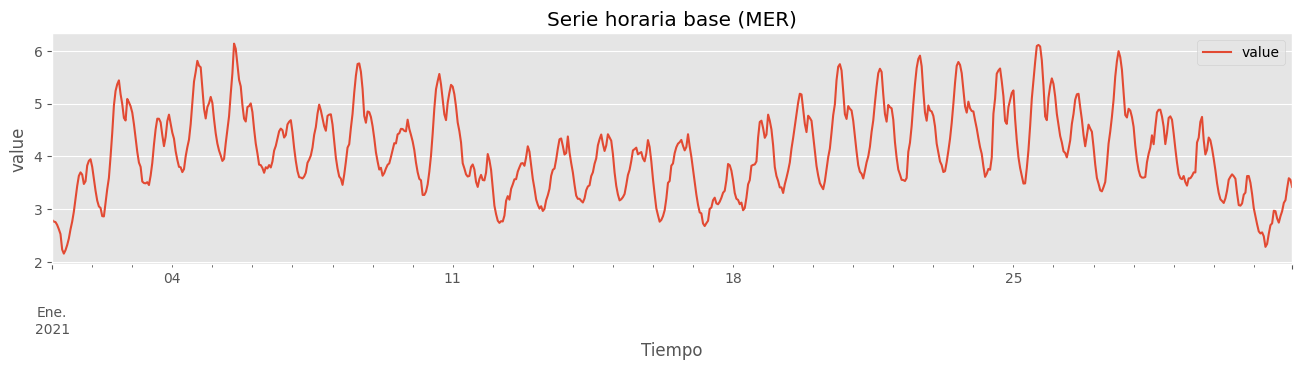

In [62]:
dta["2021-01-01":"2021-01-31"].plot(figsize=(16, 3), title="Serie horaria base (MER)")
plt.xlabel("Tiempo")
plt.ylabel("value")
plt.show()

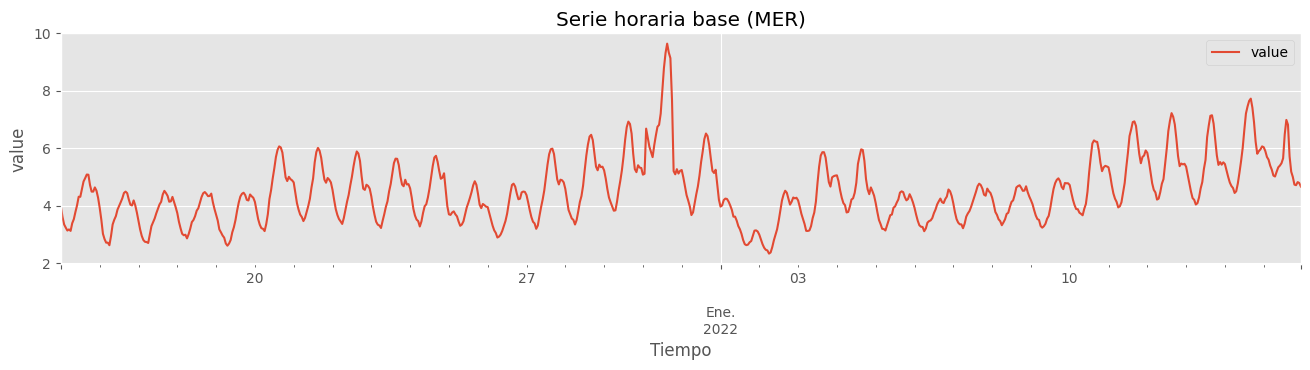

In [63]:
dta["2021-12-15":"2022-01-15"].plot(figsize=(16, 3), title="Serie horaria base (MER)")
plt.xlabel("Tiempo")
plt.ylabel("value")
plt.show()


In [64]:
# 1. Estacionalidad diaria, semanal y anual.
# 2. Hay picos tanto positivos como negativos. También hay días atípicos como  el 31 de diciembre de 2021.

## Parte 2 - Targets y features

En esta sección se trabajará sobre dos problemas de forecasting: predecir la siguiente hora (1h) y predecir la siguiente semana (1w). Para entrenar modelos con árboles es necesario generar un conjunto tabular a partir de diferentes features.

In [65]:
# El objetivo es predecir el siguiente valor (siguiente hora)
target_1h = dta.shift(-1).copy().dropna()

# El objetivo es predecir todos los valores hasta la misma hora la siguiente semana (168 horas)
target_1w = pd.concat(
    [dta["value"].shift(-k).rename(f"t+{k}") for k in range(1, 169)],
    axis=1
)
target_1w = target_1w.dropna()

target_1h.head(), target_1w.head()

(                              value
 timestamp                          
 2015-04-14 00:00:00+00:00  4.490550
 2015-04-14 01:00:00+00:00  4.210925
 2015-04-14 02:00:00+00:00  4.065475
 2015-04-14 03:00:00+00:00  4.026950
 2015-04-14 04:00:00+00:00  4.039050,
                                 t+1       t+2       t+3      t+4       t+5  \
 timestamp                                                                    
 2015-04-14 00:00:00+00:00  4.490550  4.210925  4.065475  4.02695  4.039050   
 2015-04-14 01:00:00+00:00  4.210925  4.065475  4.026950  4.03905  4.223250   
 2015-04-14 02:00:00+00:00  4.065475  4.026950  4.039050  4.22325  4.648800   
 2015-04-14 03:00:00+00:00  4.026950  4.039050  4.223250  4.64880  4.764250   
 2015-04-14 04:00:00+00:00  4.039050  4.223250  4.648800  4.76425  4.977675   
 
                                 t+6       t+7       t+8       t+9      t+10  \
 timestamp                                                                     
 2015-04-14 00:00:00+00:0

### RESPONDER

En las celda anterior se construyen dos dataframes que serán los targets de los problemas de forecasting. Discutir:

1. ¿Qué representa cada columna de target_1w?
2. ¿Cuál es la diferencia en cantidad de filas entre los datos originales (dta) y los targets? ¿Qué explica esta diferencia?

**Respuestas**


In [66]:
#TODO: Comparar diferencias.
# 1.
# Las columnas son los valores pasados a partir de la marca de tiempo. En t+1 es el valor hace una hira, en t+2 el valor de dos horas antes, y así sucesivamente hasta t+168 que es el valor hace 168 horas atras.
target_1w.head()

,t+1,t+2,t+3,t+4,t+5,t+6,t+7,t+8,t+9,t+10,...,t+159,t+160,t+161,t+162,t+163,t+164,t+165,t+166,t+167,t+168
timestamp,,,,,,,,,,,,,,,,,,,,,
2015-04-14 00:00:00+00:00,4.490550,4.210925,4.065475,4.02695,4.039050,4.223250,4.648800,4.764250,4.977675,4.949225,...,4.688550,4.862650,5.015225,5.340925,6.137650,6.220675,6.276300,5.853100,5.599975,4.951425
2015-04-14 01:00:00+00:00,4.210925,4.065475,4.026950,4.03905,4.223250,4.648800,4.764250,4.977675,4.949225,5.164075,...,4.862650,5.015225,5.340925,6.137650,6.220675,6.276300,5.853100,5.599975,4.951425,4.421800
2015-04-14 02:00:00+00:00,4.065475,4.026950,4.039050,4.22325,4.648800,4.764250,4.977675,4.949225,5.164075,5.241025,...,5.015225,5.340925,6.137650,6.220675,6.276300,5.853100,5.599975,4.951425,4.421800,4.140925
2015-04-14 03:00:00+00:00,4.026950,4.039050,4.223250,4.64880,4.764250,4.977675,4.949225,5.164075,5.241025,5.271450,...,5.340925,6.137650,6.220675,6.276300,5.853100,5.599975,4.951425,4.421800,4.140925,4.047100
2015-04-14 04:00:00+00:00,4.039050,4.223250,4.648800,4.76425,4.977675,4.949225,5.164075,5.241025,5.271450,5.318125,...,6.137650,6.220675,6.276300,5.853100,5.599975,4.951425,4.421800,4.140925,4.047100,3.925400


In [67]:
# 2. La diferencia está en que los targets de 1 semana tienen que tener todos el mismo tamaño (168) y el corrimiento es de 1 hora, 
# por lo tanto se pierden los últimos 168 registros de la serie original.
print("shape datos crudos", dta.shape)
print("shape target 1w", target_1w.shape)
print("diferencia de filas", dta.shape[0] - target_1w.shape[0])

shape datos crudos (82537, 1)
shape target 1w (82369, 168)
diferencia de filas 168


In [68]:
dta.tail()

,value
timestamp,
2024-09-11 20:00:00+00:00,-0.00375
2024-09-11 21:00:00+00:00,-0.00375
2024-09-11 22:00:00+00:00,-0.00375
2024-09-11 23:00:00+00:00,-0.00375
2024-09-12 00:00:00+00:00,-0.00400


In [69]:
target_1w.tail()

,t+1,t+2,t+3,t+4,t+5,t+6,t+7,t+8,t+9,t+10,...,t+159,t+160,t+161,t+162,t+163,t+164,t+165,t+166,t+167,t+168
timestamp,,,,,,,,,,,,,,,,,,,,,
2024-09-04 20:00:00+00:00,-0.00375,-0.00375,-0.00350,-0.00375,-0.00375,-0.00350,-0.00375,-0.00375,-0.00375,-0.00375,...,0.01575,0.1450,1.39100,1.93200,1.13600,0.97950,0.33875,0.06250,-0.00750,-0.00375
2024-09-04 21:00:00+00:00,-0.00375,-0.00350,-0.00375,-0.00375,-0.00350,-0.00375,-0.00375,-0.00375,-0.00375,0.05225,...,0.14500,1.3910,1.93200,1.13600,0.97950,0.33875,0.06250,-0.00750,-0.00375,-0.00375
2024-09-04 22:00:00+00:00,-0.00350,-0.00375,-0.00375,-0.00350,-0.00375,-0.00375,-0.00375,-0.00375,0.05225,0.59200,...,1.39100,1.9320,1.13600,0.97950,0.33875,0.06250,-0.00750,-0.00375,-0.00375,-0.00375
2024-09-04 23:00:00+00:00,-0.00375,-0.00375,-0.00350,-0.00375,-0.00375,-0.00375,-0.00375,0.05225,0.59200,1.26150,...,1.93200,1.1360,0.97950,0.33875,0.06250,-0.00750,-0.00375,-0.00375,-0.00375,-0.00375
2024-09-05 00:00:00+00:00,-0.00375,-0.00350,-0.00375,-0.00375,-0.00375,-0.00375,0.05225,0.59200,1.26150,1.75550,...,1.13600,0.9795,0.33875,0.06250,-0.00750,-0.00375,-0.00375,-0.00375,-0.00375,-0.00400


In [70]:
# Funciones para la generación de features, y para la intersección de índices entre features y targets.

def make_lag_features(df, lags):
    df_aux = df.copy()
    for lag in lags:
        df_aux[f"lag_{lag}"] = df_aux["value"].shift(lag)
    return df_aux.drop(columns=["value"]).dropna()

def make_rolling_features(df, windows):
    df_aux = df.copy()
    for w in windows:
        df_aux[f"rolling_mean_{w}"] = df_aux["value"].rolling(w).mean()
        df_aux[f"rolling_std_{w}"] = df_aux["value"].rolling(w).std()
        df_aux[f"rolling_min_{w}"] = df_aux["value"].rolling(w).min()
        df_aux[f"rolling_max_{w}"] = df_aux["value"].rolling(w).max()
    return df_aux.drop(columns=["value"]).dropna()

def make_temporal_features(df):
    df_aux = df.copy()
    df_aux["hour"] = df_aux.index.hour
    df_aux["dayofweek"] = df_aux.index.dayofweek
    df_aux["dayofmonth"] = df_aux.index.day
    df_aux["weekofyear"] = df_aux.index.isocalendar().week.astype(int)
    df_aux["month"] = df_aux.index.month
    return df_aux.drop(columns=["value"])

def index_intersection(features, target):
    idx_common = features.index.intersection(target.index)
    return features.loc[idx_common], target.loc[idx_common]

In [71]:
# Métricas de evaluación para los modelos de forecasting.
def metricas(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
    }

In [72]:
lags_base = range(0, 13)  # lags de 0 a 12 horas.
windows_base = [24, 168] # rolling windows de 1 dia y 1 semana.

dta_lagf = make_lag_features(dta, lags_base)
dta_rollf = make_rolling_features(dta, windows_base)
dta_temporalf = make_temporal_features(dta)[["hour", "dayofweek", "dayofmonth"]] #Fijarse que solo se utilizan algunas de las features que proporcionan la funcion.

dta_features = pd.concat([dta_lagf, dta_rollf, dta_temporalf], axis=1).dropna()
dta_features.head()

,lag_0,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,...,rolling_std_24,rolling_min_24,rolling_max_24,rolling_mean_168,rolling_std_168,rolling_min_168,rolling_max_168,hour,dayofweek,dayofmonth
timestamp,,,,,,,,,,,,,,,,,,,,,
2015-04-20 23:00:00+00:00,5.599975,5.853100,6.276300,6.220675,6.137650,5.340925,5.015225,4.862650,4.688550,4.601525,...,0.762660,3.7474,6.2763,4.827531,0.797078,3.224575,6.568225,23,0,20
2015-04-21 00:00:00+00:00,4.951425,5.599975,5.853100,6.276300,6.220675,6.137650,5.340925,5.015225,4.862650,4.688550,...,0.760888,3.7474,6.2763,4.826784,0.796901,3.224575,6.568225,0,1,21
2015-04-21 01:00:00+00:00,4.421800,4.951425,5.599975,5.853100,6.276300,6.220675,6.137650,5.340925,5.015225,4.862650,...,0.753675,3.7474,6.2763,4.826374,0.797093,3.224575,6.568225,1,1,21
2015-04-21 02:00:00+00:00,4.140925,4.421800,4.951425,5.599975,5.853100,6.276300,6.220675,6.137650,5.340925,5.015225,...,0.739998,3.7474,6.2763,4.825958,0.797435,3.224575,6.568225,2,1,21
2015-04-21 03:00:00+00:00,4.047100,4.140925,4.421800,4.951425,5.599975,5.853100,6.276300,6.220675,6.137650,5.340925,...,0.724126,3.7474,6.2763,4.825848,0.797541,3.224575,6.568225,3,1,21


### RESPONDER

Las celdas anteriores generan las features necesarias para entrenar los modelos de árboles. Discutir:

1. ¿Cómo cambia la cantidad de filas antes (dta) y después de la generación de las features (dta_features)? ¿Por qué?

**Respuestas**



In [73]:
#TODO: Comparar la cantidad de filas.

# 1. La diferencia es de 167 valores y se debe a los rolling con ventanas de 168 valores, que a partir de ese número de entrada te devuelven 1 valor.

print("dta.shape", dta.shape)
print("dta_features.shape", dta_features.shape)
print("diferencia de filas", dta.shape[0] - dta_features.shape[0])

dta.shape (82537, 1)
dta_features.shape (82370, 24)
diferencia de filas 167


In [74]:
# Se emparejan los features y los targets para que tengan el mismo índice temporal.
# Se divide el conjunto en train y test para ambos problemas de forecasting (1h y 1w).

dta_1h_features, dta_1h_target = index_intersection(dta_features, target_1h)
dta_1w_features, dta_1w_target = index_intersection(dta_features, target_1w)

split_train_end = "2020-05-31"
split_test_start = "2020-06-01"
split_test_end = "2020-06-30"

dta_1h_features_train = dta_1h_features[:split_train_end]
dta_1h_target_train = dta_1h_target[:split_train_end]
dta_1h_features_test = dta_1h_features[split_test_start:split_test_end]
dta_1h_target_test = dta_1h_target[split_test_start:split_test_end]

dta_1w_features_train = dta_1w_features[:split_train_end]
dta_1w_target_train = dta_1w_target[:split_train_end]
dta_1w_features_test = dta_1w_features[split_test_start:split_test_end]
dta_1w_target_test = dta_1w_target[split_test_start:split_test_end]

print(dta_1h_features_train.shape, dta_1h_features_test.shape)
print(dta_1w_features_train.shape, dta_1w_features_test.shape)

(44833, 24) (720, 24)
(44833, 24) (720, 24)


## Parte 3 - Forecasting con RandomForest y XGBoost

### Forecasting 1 hora con RandomForest

In [75]:
# Se instancia un modelo de RF para el problema de forecasting de 1 hora.
rf_1h = RandomForestRegressor(
    n_estimators=50,
    max_leaf_nodes=500,
    random_state=SEED,
    n_jobs=-1
)

# Entrenamiento
t0 = time.perf_counter()
rf_1h.fit(dta_1h_features_train.values, dta_1h_target_train.values.ravel())
rf_1h_train_time = time.perf_counter() - t0

print(f"Tiempo de entrenamiento RF 1h: {rf_1h_train_time:.2f} segundos")

# Predicción
pred_rf_1h = rf_1h.predict(dta_1h_features_test.values)

Tiempo de entrenamiento RF 1h: 7.36 segundos


In [76]:
metrics_rf_1h = metricas(dta_1h_target_test.values.ravel(), pred_rf_1h.ravel())
metrics_rf_1h

{'MAE': 0.08435957292238529,
 'MSE': 0.01293466069806998,
 'MAPE': 0.021846470707257343}

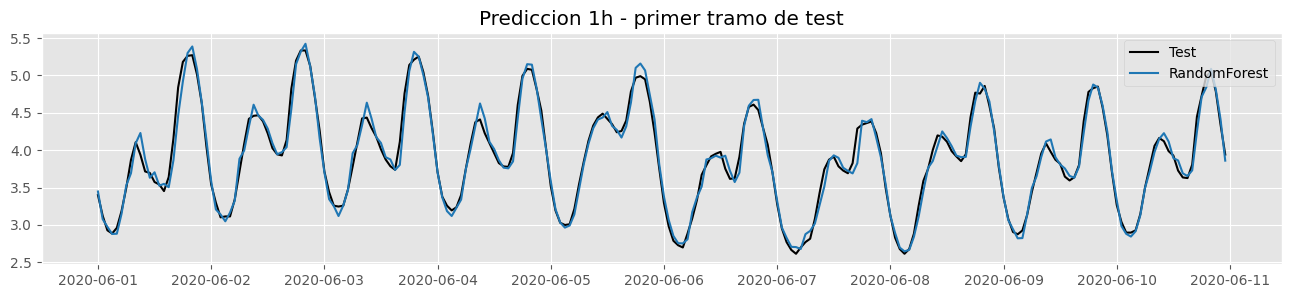

In [77]:
plt.figure(figsize=(16, 3))
plt.plot(dta_1h_target_test.index[:24 * 10], dta_1h_target_test.values[:24 * 10], label="Test", color="black")
plt.plot(dta_1h_target_test.index[:24 * 10], pred_rf_1h[:24 * 10], label="RandomForest", color="tab:blue")
plt.title("Prediccion 1h - primer tramo de test")
plt.legend(loc="best")
plt.show()

,importance
lag_0,0.935293
hour,0.032243
lag_2,0.009954
lag_1,0.005459
lag_8,0.004273
lag_9,0.002690
lag_3,0.001393
lag_7,0.001229
lag_10,0.001040
rolling_min_24,0.000926


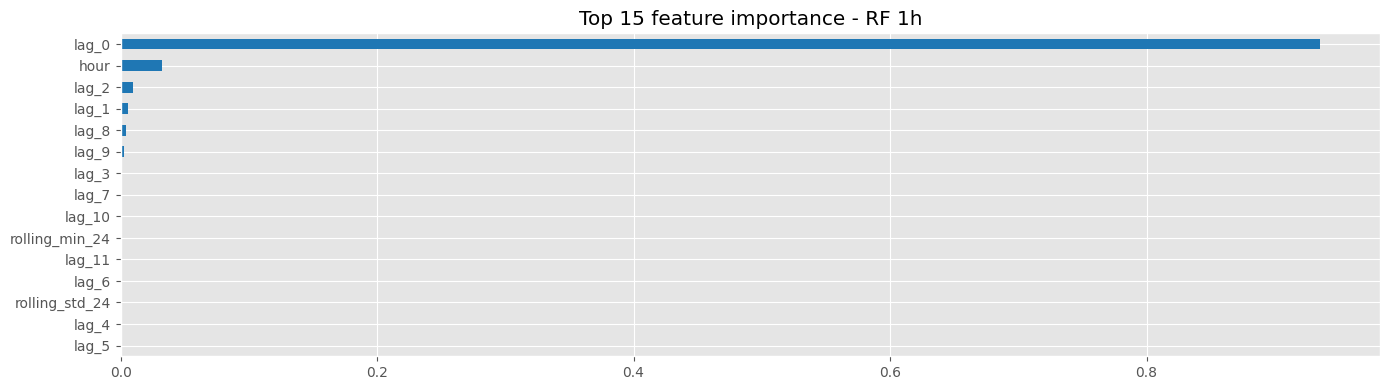

In [78]:
# Feature importance
fi_rf_1h = pd.Series(rf_1h.feature_importances_, index=dta_1h_features_train.columns).sort_values(ascending=False)
display(fi_rf_1h.head(15).to_frame("importance"))

fi_rf_1h.head(15).sort_values().plot(kind="barh", color="#1f77b4")
plt.title("Top 15 feature importance - RF 1h")
plt.tight_layout()
plt.show()

### Forecasting 1 semana con Random Forest

In [79]:
# Se instancia un modelo de RF para el problema de forecasting de 1 semana.
rf_1w = RandomForestRegressor(
    n_estimators=50,
    max_leaf_nodes=500,
    random_state=SEED,
    n_jobs=-1
)

# Entrenamiento
t0 = time.perf_counter()
rf_1w.fit(dta_1w_features_train.values, dta_1w_target_train.values)
rf_1w_train_time = time.perf_counter() - t0

print(f"Tiempo de entrenamiento RF 1w: {rf_1w_train_time:.2f} segundos")

# Predicción
pred_rf_1w = rf_1w.predict(dta_1w_features_test.values)

Tiempo de entrenamiento RF 1w: 34.65 segundos


In [80]:
# Evaluamos solo anclas semanales para comparar ventanas completas
metrics_rf_1w = metricas(dta_1w_target_test.values[::168], pred_rf_1w[::168])
metrics_rf_1w

{'MAE': 0.35902712472619147,
 'MSE': 0.20209222669633303,
 'MAPE': 0.08978496572206118}

,importance
hour,0.536134
rolling_mean_168,0.154099
rolling_mean_24,0.085176
rolling_min_168,0.052468
lag_0,0.030394
rolling_std_168,0.021181
lag_3,0.011265
rolling_max_168,0.011146
lag_6,0.009313
rolling_std_24,0.007557


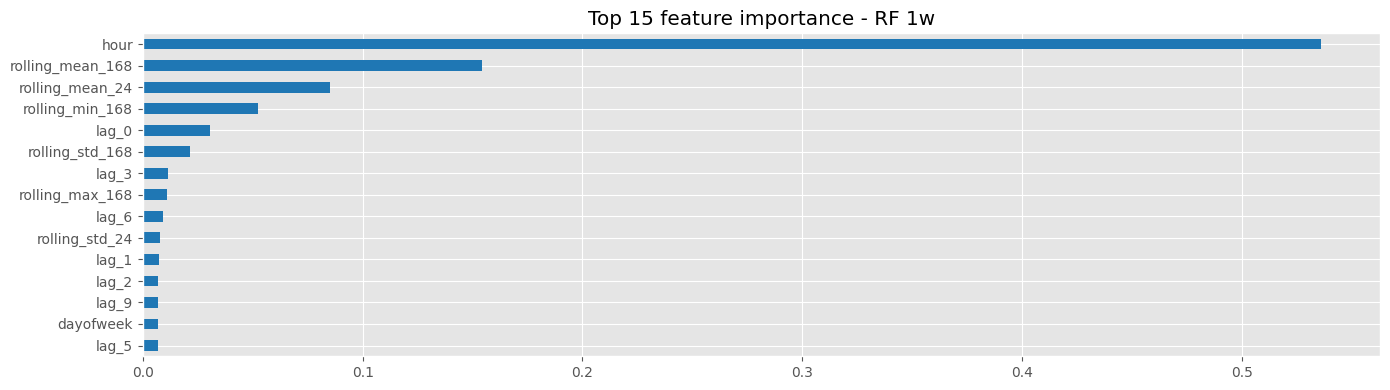

In [81]:
# Feature importance
fi_rf_1w = pd.Series(rf_1w.feature_importances_, index=dta_1w_features_train.columns).sort_values(ascending=False)
display(fi_rf_1w.head(15).to_frame("importance"))

fi_rf_1w.head(15).sort_values().plot(kind="barh", color="#1f77b4")
plt.title("Top 15 feature importance - RF 1w")
plt.tight_layout()
plt.show()

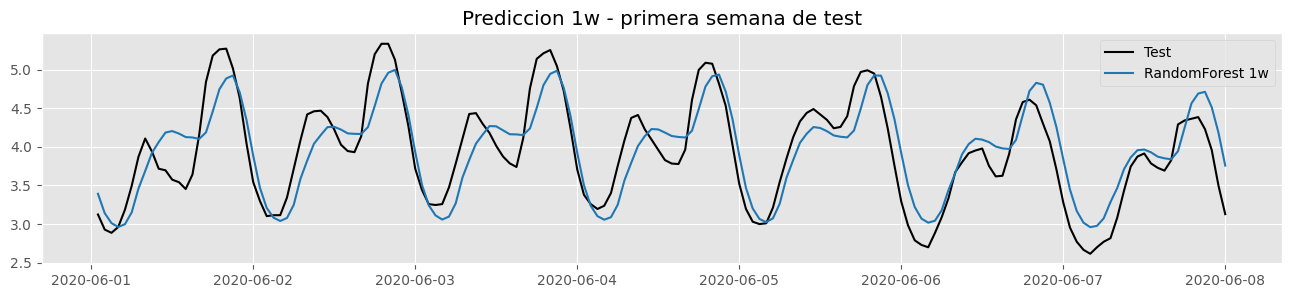

In [82]:
# Visualizacion de la primera ventana semanal pronosticada por RF
inicio = dta_1h_target_test.index[0] + pd.Timedelta(hours=1)
fin = inicio + pd.Timedelta(hours=24 * 7)

y_real = dta_1h_target_test.loc[inicio:fin].values.ravel()
x_real = dta_1h_target_test.loc[inicio:fin].index
y_pred = pred_rf_1w[0].ravel()

n = min(len(x_real), len(y_real), len(y_pred))

plt.figure(figsize=(16, 3))
plt.plot(x_real[:n], y_real[:n], label="Test", color="black")
plt.plot(x_real[:n], y_pred[:n], label="RandomForest 1w", color="tab:blue")
plt.title("Prediccion 1w - primera semana de test")
plt.legend(loc="best")
plt.show()

### DISCUTIR

1. Como cambian los errores al pasar de 1h a 1w?
2. La velocidad de entrenamiento acompaña esa dificultad?

In [83]:
print("Porcentaje de error relativo entre 1h y 1w")
for metric, value in metrics_rf_1h.items():
    print(f"{metric}: {value:.4f} - {metrics_rf_1w[metric]:.4f} - {100 * (metrics_rf_1w[metric] - value) / value:.2f}%")

Porcentaje de error relativo entre 1h y 1w
MAE: 0.0844 - 0.3590 - 325.59%
MSE: 0.0129 - 0.2021 - 1462.41%
MAPE: 0.0218 - 0.0898 - 310.98%


In [84]:
print("Diferencia de tiempo de entrenamiento entre 1h y 1w")
print(f"Tiempo de entrenamiento 1h: {rf_1h_train_time:.4f}")
print(f"Tiempo de entrenamiento 1w: {rf_1w_train_time:.4f}")
print(f"Diferencia: {rf_1w_train_time - rf_1h_train_time:.4f}")

Diferencia de tiempo de entrenamiento entre 1h y 1w
Tiempo de entrenamiento 1h: 7.3594
Tiempo de entrenamiento 1w: 34.6533
Diferencia: 27.2939


In [85]:
# Se ve un gran aumento tanto en el error como en el tiempo de entrenamiento. Se ve que el problema se complejiza al aumentar el horizonte.

### Forecasting XGBoost

### COMPLETAR Y DISCUTIR:
Repita las celdas anteriores de predicción de la siguiente hora y de la siguiente semana usando XGBoost. Compare los resultados con los obtenidos con RandomForest y discuta:

- Tiempo de entrenamiento.
- Resultados de las métricas de error.

### Forecasting 1 hora con XGBoost

In [86]:
xgb_1h = xgb.XGBRegressor(
    n_estimators=50,
    max_leaf_nodes=500,
    random_state=SEED,
    objective="reg:squarederror",
    n_jobs=-1
)

#TODO Entrenamiento, y predicción
t0 = time.perf_counter()
xgb_1h.fit(dta_1h_features_train.values, dta_1h_target_train.values.ravel())
xgb_1h_train_time = time.perf_counter() - t0

print(f"Tiempo de entrenamiento XGB 1h: {xgb_1h_train_time:.2f} segundos")

# Predicción
pred_xgb_1h = xgb_1h.predict(dta_1h_features_test.values)

Tiempo de entrenamiento XGB 1h: 0.29 segundos


In [87]:
#TODO: Feature importance para xgb_1h
metrics_xgb_1h = metricas(dta_1h_target_test.values.ravel(), pred_xgb_1h.ravel())
metrics_xgb_1h

{'MAE': 0.07894773830970128,
 'MSE': 0.011205159244153535,
 'MAPE': 0.02028023900841624}

,importance
lag_0,0.850895
hour,0.031862
lag_2,0.027937
lag_8,0.014831
lag_1,0.012249
lag_9,0.009925
lag_7,0.009595
lag_10,0.005077
lag_3,0.004354
lag_5,0.003581


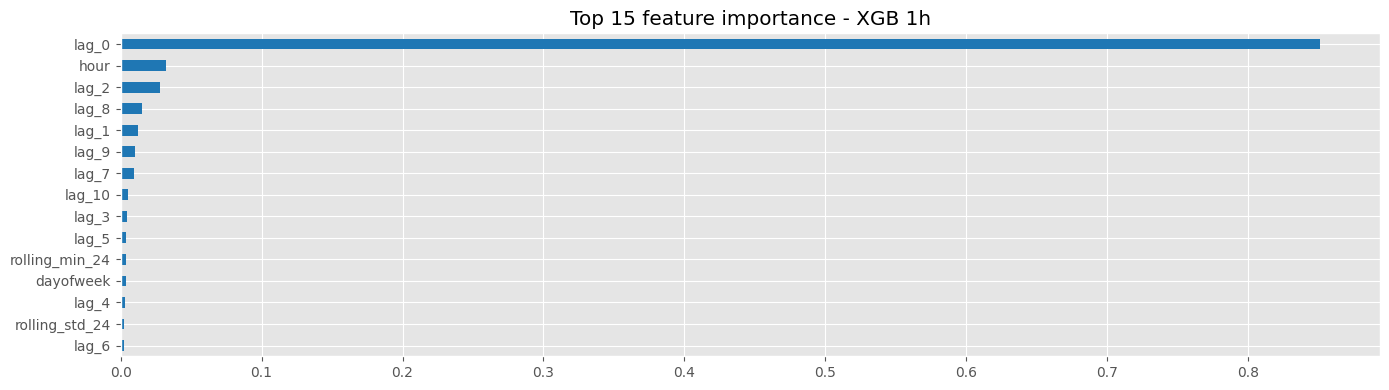

In [88]:
#TODO: Feature importance para xgb_1h
fi_xgb_1h = pd.Series(xgb_1h.feature_importances_, index=dta_1h_features_train.columns).sort_values(ascending=False)
display(fi_xgb_1h.head(15).to_frame("importance"))

fi_xgb_1h.head(15).sort_values().plot(kind="barh", color="#1f77b4")
plt.title("Top 15 feature importance - XGB 1h")
plt.tight_layout()
plt.show()

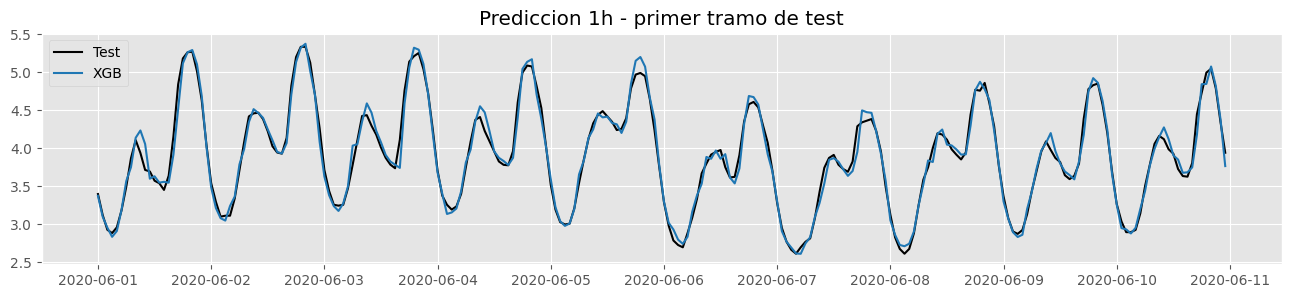

In [89]:
#TODO: Plot de la primer semana de test pronosticada por XGBoost

plt.figure(figsize=(16, 3))
plt.plot(dta_1h_target_test.index[:24 * 10], dta_1h_target_test.values[:24 * 10], label="Test", color="black")
plt.plot(dta_1h_target_test.index[:24 * 10], pred_xgb_1h[:24 * 10], label="XGB", color="tab:blue")
plt.title("Prediccion 1h - primer tramo de test")
plt.legend(loc="best")
plt.show()

### Forecasting 1 semana XGBoost

In [90]:
xgb_1w = xgb.XGBRegressor(
    n_estimators=50,
    max_leaf_nodes=500,
    random_state=SEED,
    objective="reg:squarederror",
    n_jobs=-1
)

#TODO: Entrenamiento, y predicción
t0 = time.perf_counter()
xgb_1w.fit(dta_1w_features_train.values, dta_1w_target_train.values)
xgb_1w_train_time = time.perf_counter() - t0

print(f"Tiempo de entrenamiento XGB 1w: {xgb_1w_train_time:.2f} segundos")

# Predicción
pred_xgb_1w = xgb_1w.predict(dta_1w_features_test.values)

Tiempo de entrenamiento XGB 1w: 28.29 segundos


In [91]:
#TODO: Calcular métricas de desempeño
metrics_xgb_1w = metricas(dta_1w_target_test.values[::168], pred_xgb_1w[::168])
metrics_xgb_1w

{'MAE': 0.3487132807572683,
 'MSE': 0.19760916524113584,
 'MAPE': 0.08929311820417529}

,importance
hour,0.117108
lag_12,0.071615
lag_9,0.057845
lag_11,0.057668
lag_8,0.057429
lag_10,0.057003
lag_7,0.055782
lag_6,0.052820
lag_3,0.052805
lag_4,0.051559


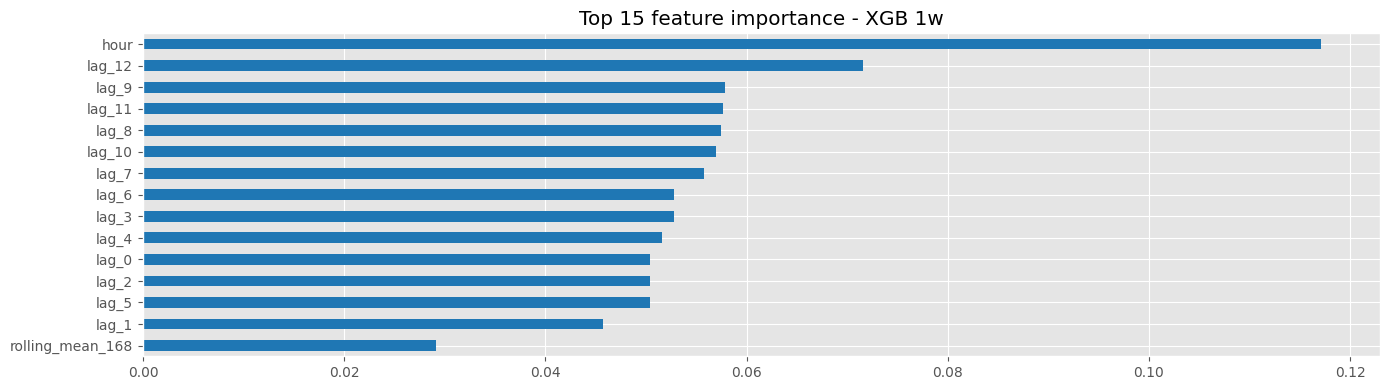

In [92]:
#TODO: Feature importance para xgb_1w
fi_xgb_1w = pd.Series(xgb_1w.feature_importances_, index=dta_1w_features_train.columns).sort_values(ascending=False)
display(fi_xgb_1w.head(15).to_frame("importance"))

fi_xgb_1w.head(15).sort_values().plot(kind="barh", color="#1f77b4")
plt.title("Top 15 feature importance - XGB 1w")
plt.tight_layout()
plt.show()

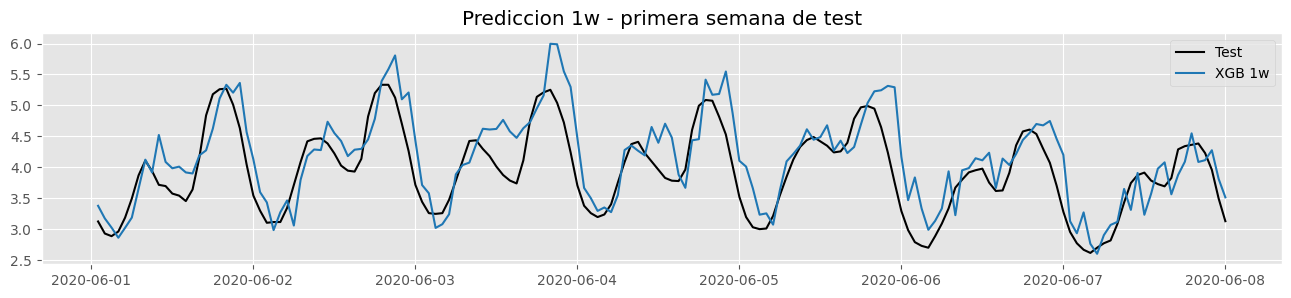

In [93]:
#TODO: Visualizacion de la primera ventana semanal pronosticada por XGBoost
inicio = dta_1h_target_test.index[0] + pd.Timedelta(hours=1)
fin = inicio + pd.Timedelta(hours=24 * 7)

y_real = dta_1h_target_test.loc[inicio:fin].values.ravel()
x_real = dta_1h_target_test.loc[inicio:fin].index
y_pred = pred_xgb_1w[0].ravel()

n = min(len(x_real), len(y_real), len(y_pred))

plt.figure(figsize=(16, 3))
plt.plot(x_real[:n], y_real[:n], label="Test", color="black")
plt.plot(x_real[:n], y_pred[:n], label="XGB 1w", color="tab:blue")
plt.title("Prediccion 1w - primera semana de test")
plt.legend(loc="best")
plt.show()

## Parte 4 - EXPERIMENTAR con diferentes features

Utilizando las funciones de generación de features, probar agregar o quitar features que le parezcan relevantes para mejorar el desempeño de los modelos anteriores. Por ejemplo, agregar otras lags o features temporales.



DISCUTIR:
1. Como impactaron en el desempeño del forecasting.
2. Como cambiaron las conclusiones sobre la importancia de las features tanto para el problema de 1h como para el de 1w.
3. Como impactaron en el tiempo de entrenamiento.

In [94]:
#TODO: completar la generación de features.

lags_base = range(0, 48)  # lags de 0 a 48 horas.

dta_lagf_dif = make_lag_features(dta, lags_base)
dta_rollf_dif = make_rolling_features(dta, windows_base)
dta_temp_dif = make_temporal_features(dta) # Se 

dta_features_dif = pd.concat([dta_lagf_dif, dta_rollf_dif, dta_temp_dif], axis=1).dropna()
dta_1h_features_dif, dta_1h_target_dif = index_intersection(dta_features_dif, target_1h)
dta_1w_features_dif, dta_1w_target_dif = index_intersection(dta_features_dif, target_1w)

dta_1h_features_dif_train = dta_1h_features_dif[:split_train_end]
dta_1h_target_dif_train = dta_1h_target_dif[:split_train_end]
dta_1h_features_dif_test = dta_1h_features_dif[split_test_start:split_test_end]
dta_1h_target_dif_test = dta_1h_target_dif[split_test_start:split_test_end]

dta_1w_features_dif_train = dta_1w_features_dif[:split_train_end]
dta_1w_target_dif_train = dta_1w_target_dif[:split_train_end]
dta_1w_features_dif_test = dta_1w_features_dif[split_test_start:split_test_end]
dta_1w_target_dif_test = dta_1w_target_dif[split_test_start:split_test_end]

print(dta_1h_features_dif_train.shape, dta_1h_features_dif_test.shape)
print(dta_1w_features_dif_train.shape, dta_1w_features_dif_test.shape)

(44833, 61) (720, 61)
(44833, 61) (720, 61)


In [95]:
# TODO: Entrenar y evaluar modelos de RF y XGBoost con las nuevas features, y comparar resultados con los obtenidos previamente.

In [96]:
# Se instancia un modelo de RF para el problema de forecasting de 1 hora.
rf_1h_dif = RandomForestRegressor(
    n_estimators=50,
    max_leaf_nodes=500,
    random_state=SEED,
    n_jobs=-1
)

# Entrenamiento
t0 = time.perf_counter()
rf_1h_dif.fit(dta_1h_features_dif_train.values, dta_1h_target_dif_train.values.ravel())
rf_1h_dif_train_time = time.perf_counter() - t0

print(f"Tiempo de entrenamiento RF 1h: {rf_1h_dif_train_time:.2f} segundos")

# Predicción
pred_rf_1h_dif = rf_1h_dif.predict(dta_1h_features_dif_test.values)

Tiempo de entrenamiento RF 1h: 19.51 segundos


In [97]:
metrics_rf_1h_dif = metricas(dta_1h_target_dif_test.values.ravel(), pred_rf_1h_dif.ravel())
metrics_rf_1h_dif

{'MAE': 0.08177377541654787,
 'MSE': 0.01155715591945055,
 'MAPE': 0.02129211018770573}

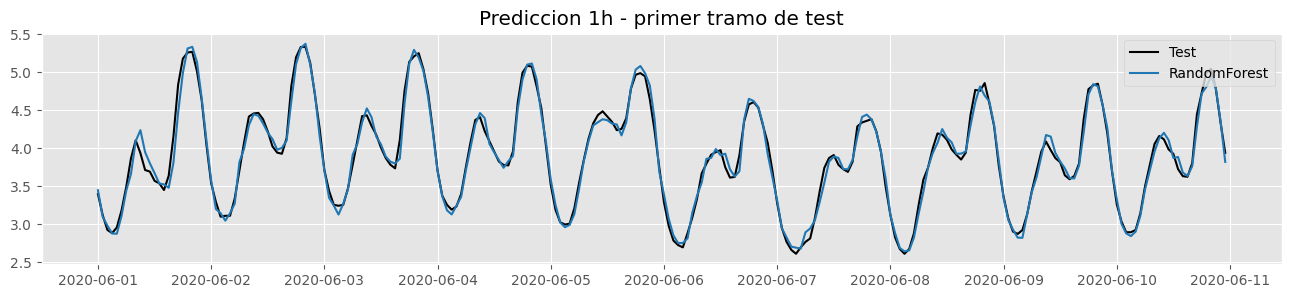

In [98]:
plt.figure(figsize=(16, 3))
plt.plot(dta_1h_target_dif_test.index[:24 * 10], dta_1h_target_dif_test.values[:24 * 10], label="Test", color="black")
plt.plot(dta_1h_target_dif_test.index[:24 * 10], pred_rf_1h_dif[:24 * 10], label="RandomForest", color="tab:blue")
plt.title("Prediccion 1h - primer tramo de test")
plt.legend(loc="best")
plt.show()

,importance
lag_0,0.928302
lag_21,0.021093
hour,0.013428
lag_22,0.011294
lag_1,0.003444
lag_26,0.002881
lag_27,0.002865
lag_25,0.002353
lag_2,0.001802
lag_8,0.001156


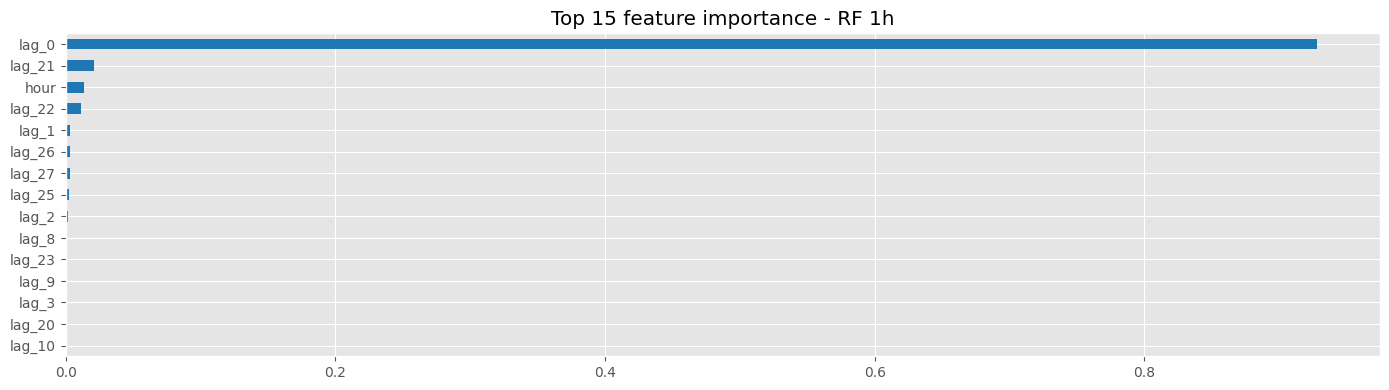

In [99]:
# Feature importance
fi_rf_1h_dif = pd.Series(rf_1h_dif.feature_importances_, index=dta_1h_features_dif_train.columns).sort_values(ascending=False)
display(fi_rf_1h_dif.head(15).to_frame("importance"))

fi_rf_1h_dif.head(15).sort_values().plot(kind="barh", color="#1f77b4")
plt.title("Top 15 feature importance - RF 1h")
plt.tight_layout()
plt.show()

### Forecasting 1 semana con Random Forest Dif

In [100]:
# Se instancia un modelo de RF para el problema de forecasting de 1 semana.
rf_1w_dif = RandomForestRegressor(
    n_estimators=50,
    max_leaf_nodes=500,
    random_state=SEED,
    n_jobs=-1
)

# Entrenamiento
t0 = time.perf_counter()
rf_1w_dif.fit(dta_1w_features_dif_train.values, dta_1w_target_dif_train.values)
rf_1w_dif_train_time = time.perf_counter() - t0

print(f"Tiempo de entrenamiento RF 1w dif: {rf_1w_dif_train_time:.2f} segundos")

# Predicción
pred_rf_1w_dif = rf_1w_dif.predict(dta_1w_features_dif_test.values)

Tiempo de entrenamiento RF 1w dif: 95.98 segundos


In [101]:
# Evaluamos solo anclas semanales para comparar ventanas completas
metrics_rf_1w_dif = metricas(dta_1w_target_test.values[::168], pred_rf_1w_dif[::168])
metrics_rf_1w_dif

{'MAE': 0.3475455569309076,
 'MSE': 0.1918872228756274,
 'MAPE': 0.08716104239072561}

,importance
hour,0.524217
rolling_mean_168,0.141024
rolling_mean_24,0.081380
weekofyear,0.061302
rolling_min_168,0.048706
month,0.027513
lag_0,0.021558
rolling_std_168,0.012133
rolling_max_168,0.007333
lag_3,0.006110


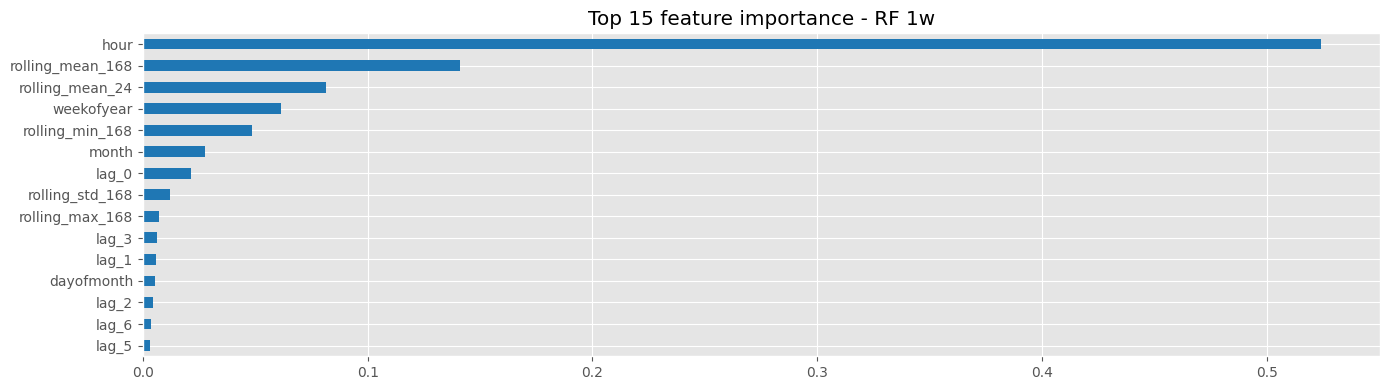

In [102]:
fi_rf_1w_dif = pd.Series(rf_1w_dif.feature_importances_, index=dta_1w_features_dif_train.columns).sort_values(ascending=False)
display(fi_rf_1w_dif.head(15).to_frame("importance"))

fi_rf_1w_dif.head(15).sort_values().plot(kind="barh", color="#1f77b4")
plt.title("Top 15 feature importance - RF 1w")
plt.tight_layout()
plt.show()


### Forecasting 1 hora con XGBoost Dif

In [103]:
xgb_1h_dif = xgb.XGBRegressor(
    n_estimators=50,
    max_leaf_nodes=500,
    random_state=SEED,
    objective="reg:squarederror",
    n_jobs=-1
)   

t0 = time.perf_counter()
xgb_1h_dif.fit(dta_1h_features_dif_train.values, dta_1h_target_dif_train.values.ravel())
xgb_1h_dif_train_time = time.perf_counter() - t0

print(f"Tiempo de entrenamiento XGB 1h dif: {xgb_1h_dif_train_time:.2f} segundos")      

pred_xgb_1h_dif = xgb_1h_dif.predict(dta_1h_features_dif_test.values)

Tiempo de entrenamiento XGB 1h dif: 0.45 segundos


In [104]:
metrics_xgb_1h_dif = metricas(dta_1h_target_dif_test.values.ravel(), pred_xgb_1h_dif.ravel())   
metrics_xgb_1h_dif

{'MAE': 0.07572290185425017,
 'MSE': 0.010271619873935626,
 'MAPE': 0.019520671073357657}

,importance
lag_0,0.713138
lag_21,0.058965
lag_22,0.038146
lag_26,0.015974
hour,0.015090
lag_27,0.013553
lag_45,0.012715
lag_25,0.010323
lag_8,0.008985
lag_46,0.008898


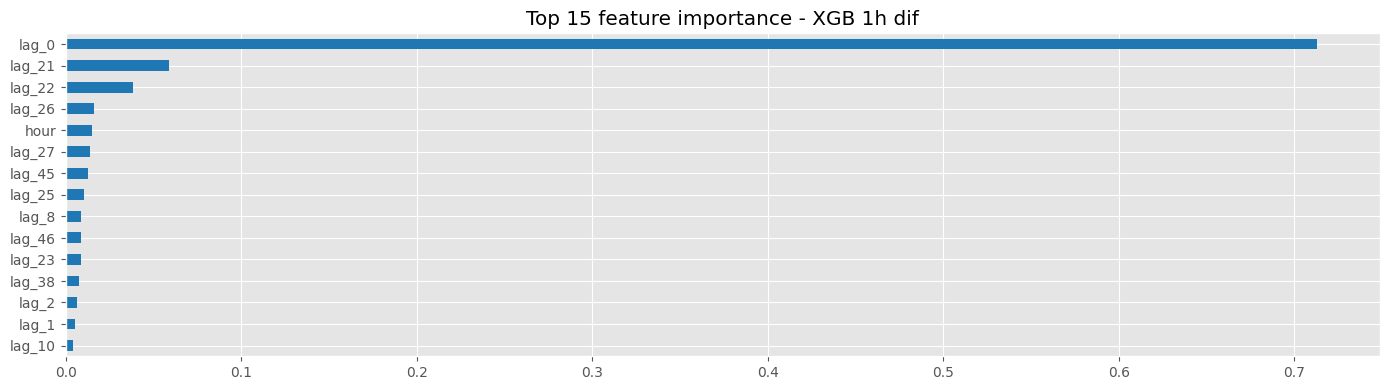

In [105]:
fi_xgb_1h_dif = pd.Series(xgb_1h_dif.feature_importances_, index=dta_1h_features_dif_train.columns).sort_values(ascending=False)    
display(fi_xgb_1h_dif.head(15).to_frame("importance"))

fi_xgb_1h_dif.head(15).sort_values().plot(kind="barh", color="#1f77b4")
plt.title("Top 15 feature importance - XGB 1h dif")
plt.tight_layout()
plt.show()  

### Forecasting 1 semana con XGBoost Dif

In [106]:
xgb_1w_dif = xgb.XGBRegressor(
    n_estimators=50,
    max_leaf_nodes=500,
    random_state=SEED,
    objective="reg:squarederror",
    n_jobs=-1
)

t0 = time.perf_counter()
xgb_1w_dif.fit(dta_1w_features_dif_train.values, dta_1w_target_dif_train.values)
xgb_1w_dif_train_time = time.perf_counter() - t0

print(f"Tiempo de entrenamiento XGB 1w dif: {xgb_1w_dif_train_time:.2f} segundos")

pred_xgb_1w_dif = xgb_1w_dif.predict(dta_1w_features_dif_test.values)

Tiempo de entrenamiento XGB 1w dif: 70.22 segundos


In [107]:
metrics_xgb_1w_dif = metricas(dta_1w_target_test.values[::168], pred_xgb_1w_dif[::168]) 
metrics_xgb_1w_dif

{'MAE': 0.34231976284867244,
 'MSE': 0.1893218043051584,
 'MAPE': 0.08786703225703299}

,importance
lag_19,0.030385
lag_20,0.029506
lag_21,0.029297
lag_18,0.028935
lag_17,0.028631
lag_15,0.027755
lag_16,0.027420
lag_14,0.027003
lag_12,0.026873
lag_22,0.026866


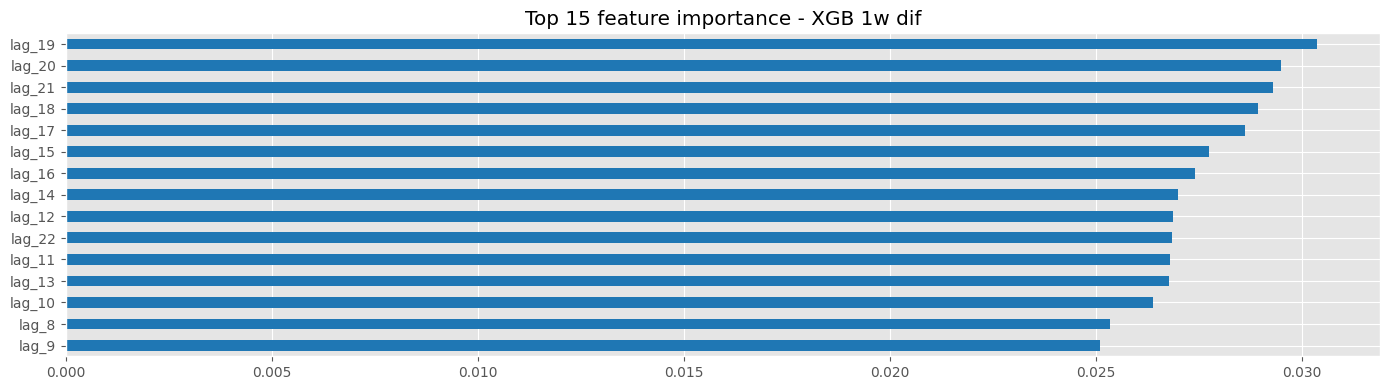

In [108]:
fi_xgb_1w_dif = pd.Series(xgb_1w_dif.feature_importances_, index=dta_1w_features_dif_train.columns).sort_values(ascending=False)
display(fi_xgb_1w_dif.head(15).to_frame("importance"))

fi_xgb_1w_dif.head(15).sort_values().plot(kind="barh", color="#1f77b4")
plt.title("Top 15 feature importance - XGB 1w dif")
plt.tight_layout()
plt.show()

### Reducción de features a partir del feature importance de los modelos de árboles

In [109]:
lags_base = [0, 21, 22, 26]

dta_lagf_less = make_lag_features(dta, lags_base)
dta_rollf_less = make_rolling_features(dta, windows_base)[["rolling_mean_24", "rolling_mean_168", "rolling_min_24"]]
dta_temp_less = make_temporal_features(dta)[["hour", "weekofyear", "month"]]

dta_features_less = pd.concat([dta_lagf_less, dta_rollf_less, dta_temp_less], axis=1).dropna()
dta_1h_features_less, dta_1h_target_less = index_intersection(dta_features_less, target_1h)
dta_1w_features_less, dta_1w_target_less = index_intersection(dta_features_less, target_1w)

dta_1h_features_less_train = dta_1h_features_less[:split_train_end]
dta_1h_target_less_train = dta_1h_target_less[:split_train_end]
dta_1h_features_less_test = dta_1h_features_less[split_test_start:split_test_end]
dta_1h_target_less_test = dta_1h_target_less[split_test_start:split_test_end]

dta_1w_features_less_train = dta_1w_features_less[:split_train_end]
dta_1w_target_less_train = dta_1w_target_less[:split_train_end]
dta_1w_features_less_test = dta_1w_features_less[split_test_start:split_test_end]
dta_1w_target_less_test = dta_1w_target_less[split_test_start:split_test_end]

print(dta_1h_features_less_train.shape, dta_1h_features_less_test.shape)
print(dta_1w_features_less_train.shape, dta_1w_features_less_test.shape)

(44833, 10) (720, 10)
(44833, 10) (720, 10)


In [110]:
rf_1h_less = RandomForestRegressor(
    n_estimators=50,
    max_leaf_nodes=500,     
    random_state=SEED,
    n_jobs=-1
)

t0 = time.perf_counter()
rf_1h_less.fit(dta_1h_features_less_train, dta_1h_target_less_train)
rf_1h_less_train_time = time.perf_counter() - t0

print(f"Tiempo de entrenamiento RF 1h less: {rf_1h_less_train_time:.2f} segundos")

pred_rf_1h_less = rf_1h_less.predict(dta_1h_features_less_test)

Tiempo de entrenamiento RF 1h less: 3.38 segundos


In [111]:
metrics_rf_1h_less = metricas(dta_1h_target_less_test.values.ravel(), pred_rf_1h_less.ravel())
metrics_rf_1h_less

{'MAE': 0.09186268927751959,
 'MSE': 0.01417516216865213,
 'MAPE': 0.02378359637446115}

,importance
lag_0,0.930911
lag_21,0.022841
hour,0.016106
lag_22,0.014708
lag_26,0.012482
rolling_min_24,0.000911
rolling_mean_24,0.000859
weekofyear,0.000530
rolling_mean_168,0.000490
month,0.000163


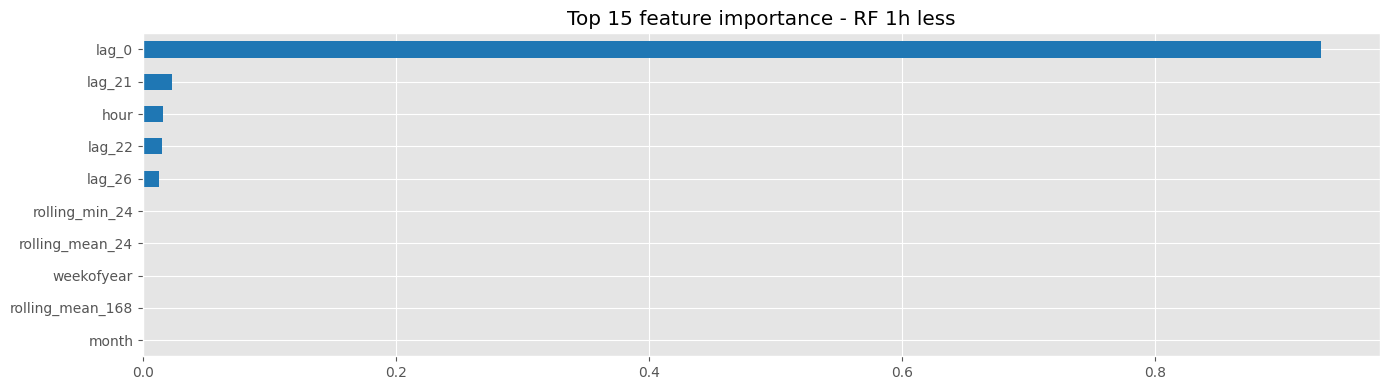

In [112]:
fi_rf_1h_less = pd.Series(rf_1h_less.feature_importances_, index=dta_1h_features_less_train.columns).sort_values(ascending=False)
display(fi_rf_1h_less.head(15).to_frame("importance"))

fi_rf_1h_less.head(15).sort_values().plot(kind="barh", color="#1f77b4")
plt.title("Top 15 feature importance - RF 1h less")
plt.tight_layout()
plt.show()

In [113]:
rf_1w_less = RandomForestRegressor(
    n_estimators=50,  
    max_leaf_nodes=500,
    random_state=SEED,
    n_jobs=-1
)

t0 = time.perf_counter()
rf_1w_less.fit(dta_1w_features_less_train, dta_1w_target_less_train)
rf_1w_less_train_time = time.perf_counter() - t0

print(f"Tiempo de entrenamiento RF 1w less: {rf_1w_less_train_time:.2f} segundos")  

pred_rf_1w_less = rf_1w_less.predict(dta_1w_features_less_test)                                 

Tiempo de entrenamiento RF 1w less: 16.13 segundos


In [114]:
metrics_rf_1w_less = metricas(dta_1w_target_less_test.values.ravel(), pred_rf_1w_less.ravel())
metrics_rf_1w_less

{'MAE': 0.32969033702268824,
 'MSE': 0.17903605650017856,
 'MAPE': 0.08372054358840308}

,importance
hour,0.533374
rolling_mean_168,0.191422
rolling_mean_24,0.095963
weekofyear,0.085861
lag_0,0.039710
month,0.035476
rolling_min_24,0.009372
lag_21,0.003379
lag_26,0.003326
lag_22,0.002117


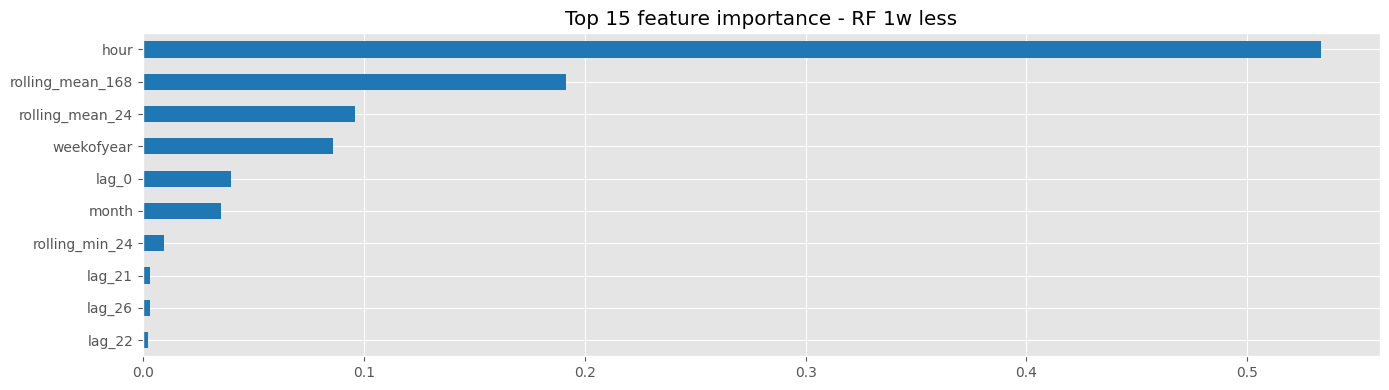

In [115]:
fi_rf_1w_less = pd.Series(rf_1w_less.feature_importances_, index=dta_1w_features_less_train.columns).sort_values(ascending=False)
display(fi_rf_1w_less.head(15).to_frame("importance"))

fi_rf_1w_less.head(15).sort_values().plot(kind="barh", color="#1f77b4")
plt.title("Top 15 feature importance - RF 1w less")
plt.tight_layout()
plt.show()

### XGBoost con menos features

In [116]:
xgb_1h_less = xgb.XGBRegressor(
    n_estimators=50,
    max_leaf_nodes=500,
    random_state=SEED,
    objective="reg:squarederror",
    n_jobs=-1
)

t0 = time.perf_counter()
xgb_1h_less.fit(dta_1h_features_less_train.values, dta_1h_target_less_train.values.ravel())
xgb_1h_less_train_time = time.perf_counter() - t0

print(f"Tiempo de entrenamiento XGB 1h less: {xgb_1h_less_train_time:.2f} segundos")    

pred_xgb_1h_less = xgb_1h_less.predict(dta_1h_features_less_test.values)

Tiempo de entrenamiento XGB 1h less: 0.16 segundos


In [117]:
metrics_xgb_1h_less = metricas(dta_1h_target_less_test.values.ravel(), pred_xgb_1h_less.ravel())
metrics_xgb_1h_less

{'MAE': 0.08240276575088501,
 'MSE': 0.012218019497236979,
 'MAPE': 0.02139916541121915}

,importance
lag_0,0.888513
lag_22,0.034159
lag_21,0.031695
hour,0.016053
lag_26,0.016008
weekofyear,0.003649
month,0.003600
rolling_mean_24,0.002561
rolling_min_24,0.002318
rolling_mean_168,0.001445


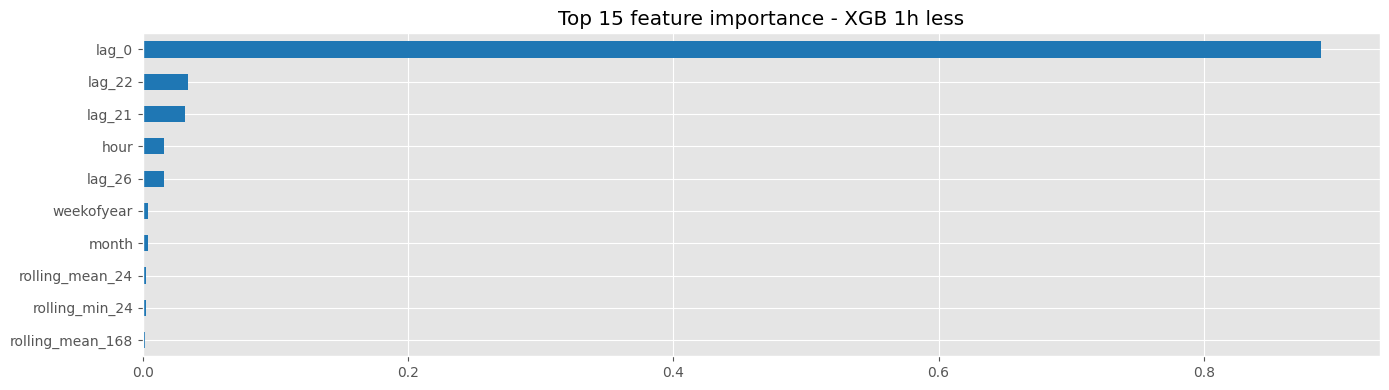

In [118]:
fi_xgb_1h_less = pd.Series(xgb_1h_less.feature_importances_, index=dta_1h_features_less_train.columns).sort_values(ascending=False)
display(fi_xgb_1h_less.head(15).to_frame("importance"))

fi_xgb_1h_less.head(15).sort_values().plot(kind="barh", color="#1f77b4")
plt.title("Top 15 feature importance - XGB 1h less")
plt.tight_layout()
plt.show()  

In [119]:
xgb_1w_less = xgb.XGBRegressor(
    n_estimators=50,
    max_leaf_nodes=500,
    random_state=SEED,
    objective="reg:squarederror",
    n_jobs=-1
)

t0 = time.perf_counter()
xgb_1w_less.fit(dta_1w_features_less_train.values, dta_1w_target_less_train.values)
xgb_1w_less_train_time = time.perf_counter() - t0

print(f"Tiempo de entrenamiento XGB 1w less: {xgb_1w_less_train_time:.2f} segundos")    

pred_xgb_1w_less = xgb_1w_less.predict(dta_1w_features_less_test.values)    

Tiempo de entrenamiento XGB 1w less: 23.20 segundos


In [120]:
metrics_xgb_1w_less = metricas(dta_1w_target_less_test.values.ravel(), pred_xgb_1w_less.ravel())
metrics_xgb_1w_less

{'MAE': 0.30232383287930614,
 'MSE': 0.15459332302425158,
 'MAPE': 0.07622108550189573}

,importance
hour,0.316075
lag_21,0.125658
lag_26,0.104605
lag_0,0.102125
month,0.079881
lag_22,0.077080
rolling_mean_168,0.062087
rolling_mean_24,0.051407
weekofyear,0.050044
rolling_min_24,0.031040


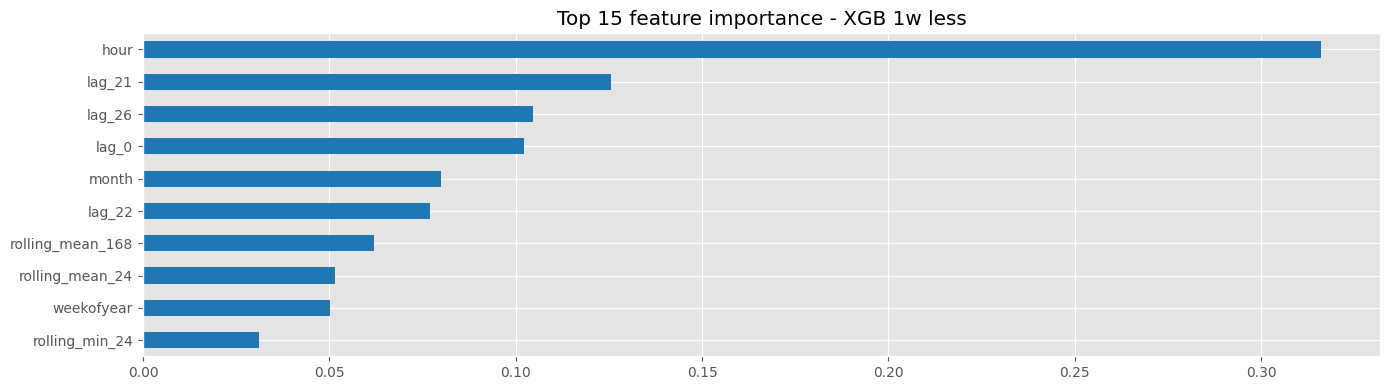

In [121]:
fi_xgb_1w_less = pd.Series(xgb_1w_less.feature_importances_, index=dta_1w_features_less_train.columns).sort_values(ascending=False)
display(fi_xgb_1w_less.head(15).to_frame("importance"))
fi_xgb_1w_less.head(15).sort_values().plot(kind="barh", color="#1f77b4")
plt.title("Top 15 feature importance - XGB 1w less")
plt.tight_layout()
plt.show()

In [122]:
comparison_df = pd.DataFrame([
    {"modelo": "RF_1h",       "horizonte": "1h", "features": dta_1h_features_train.shape[1],     "MAE": metrics_rf_1h["MAE"],      "MSE": metrics_rf_1h["MSE"],      "MAPE": metrics_rf_1h["MAPE"],      "train_time": rf_1h_train_time},
    {"modelo": "RF_1w",       "horizonte": "1w", "features": dta_1w_features_train.shape[1],     "MAE": metrics_rf_1w["MAE"],      "MSE": metrics_rf_1w["MSE"],      "MAPE": metrics_rf_1w["MAPE"],      "train_time": rf_1w_train_time},
    {"modelo": "XGB_1h",      "horizonte": "1h", "features": dta_1h_features_train.shape[1],     "MAE": metrics_xgb_1h["MAE"],     "MSE": metrics_xgb_1h["MSE"],     "MAPE": metrics_xgb_1h["MAPE"],     "train_time": xgb_1h_train_time},
    {"modelo": "XGB_1w",      "horizonte": "1w", "features": dta_1w_features_train.shape[1],     "MAE": metrics_xgb_1w["MAE"],     "MSE": metrics_xgb_1w["MSE"],     "MAPE": metrics_xgb_1w["MAPE"],     "train_time": xgb_1w_train_time},
    {"modelo": "RF_1h_dif",   "horizonte": "1h", "features": dta_1h_features_dif_train.shape[1], "MAE": metrics_rf_1h_dif["MAE"],  "MSE": metrics_rf_1h_dif["MSE"],  "MAPE": metrics_rf_1h_dif["MAPE"],  "train_time": rf_1h_dif_train_time},
    {"modelo": "RF_1w_dif",   "horizonte": "1w", "features": dta_1w_features_dif_train.shape[1], "MAE": metrics_rf_1w_dif["MAE"],  "MSE": metrics_rf_1w_dif["MSE"],  "MAPE": metrics_rf_1w_dif["MAPE"],  "train_time": rf_1w_dif_train_time},
    {"modelo": "XGB_1h_dif",  "horizonte": "1h", "features": dta_1h_features_dif_train.shape[1], "MAE": metrics_xgb_1h_dif["MAE"], "MSE": metrics_xgb_1h_dif["MSE"], "MAPE": metrics_xgb_1h_dif["MAPE"], "train_time": xgb_1h_dif_train_time},
    {"modelo": "XGB_1w_dif",  "horizonte": "1w", "features": dta_1w_features_dif_train.shape[1], "MAE": metrics_xgb_1w_dif["MAE"], "MSE": metrics_xgb_1w_dif["MSE"], "MAPE": metrics_xgb_1w_dif["MAPE"], "train_time": xgb_1w_dif_train_time},
    {"modelo": "RF_1h_less",  "horizonte": "1h", "features": dta_1h_features_less_train.shape[1],"MAE": metrics_rf_1h_less["MAE"], "MSE": metrics_rf_1h_less["MSE"], "MAPE": metrics_rf_1h_less["MAPE"], "train_time": rf_1h_less_train_time},
    {"modelo": "RF_1w_less",  "horizonte": "1w", "features": dta_1w_features_less_train.shape[1],"MAE": metrics_rf_1w_less["MAE"], "MSE": metrics_rf_1w_less["MSE"], "MAPE": metrics_rf_1w_less["MAPE"], "train_time": rf_1w_less_train_time},
    {"modelo": "XGB_1h_less", "horizonte": "1h", "features": dta_1h_features_less_train.shape[1],"MAE": metrics_xgb_1h_less["MAE"],"MSE": metrics_xgb_1h_less["MSE"],"MAPE": metrics_xgb_1h_less["MAPE"],"train_time": xgb_1h_less_train_time},
    {"modelo": "XGB_1w_less", "horizonte": "1w", "features": dta_1w_features_less_train.shape[1],"MAE": metrics_xgb_1w_less["MAE"],"MSE": metrics_xgb_1w_less["MSE"],"MAPE": metrics_xgb_1w_less["MAPE"],"train_time": xgb_1w_less_train_time}  
])

#comparison_df = comparison_df.sort_values(["horizonte", "MAE"]).reset_index(drop=True)
comparison_df.style.format({
    "MAE": "{:.4f}", "MSE": "{:.4f}", "MAPE": "{:.4f}", "train_time": "{:.2f}s"
}).background_gradient(subset=["MAE", "MSE", "MAPE"], cmap="RdYlGn_r")

,modelo,horizonte,features,MAE,MSE,MAPE,train_time
0,RF_1h,1h,24,0.0844,0.0129,0.0218,7.36s
1,RF_1w,1w,24,0.3590,0.2021,0.0898,34.65s
2,XGB_1h,1h,24,0.0789,0.0112,0.0203,0.29s
3,XGB_1w,1w,24,0.3487,0.1976,0.0893,28.29s
4,RF_1h_dif,1h,61,0.0818,0.0116,0.0213,19.51s
5,RF_1w_dif,1w,61,0.3475,0.1919,0.0872,95.98s
6,XGB_1h_dif,1h,61,0.0757,0.0103,0.0195,0.45s
7,XGB_1w_dif,1w,61,0.3423,0.1893,0.0879,70.22s
8,RF_1h_less,1h,10,0.0919,0.0142,0.0238,3.38s
9,RF_1w_less,1w,10,0.3297,0.1790,0.0837,16.13s


### Conclusiones

Se puede ver que al agregar features (de 24 a 61) se obtiene una leve mejora. A partir de estas pruebas mirando el feature importance se creo un 
nuevo dataset con las features más importantes (10 features), y si bien en los modelos para la predicción de la siguiente hora los resultados empeoran, pero levemente, en el caso de la predicción de la siguiente semana los resultados mejoran. Pero sobre todo se puede ver que para los modelos con menos features el tiempo de entrenamiento se reduce en 1/3 o 1/2. Si bien en este ejemplo ninguno de los tiempos es criticos, en una aplicación real esto puede ser un factor determinante para la elección de un modelo u otro.

## Parte 5 - Deep Learning: RNN vs CNN 1D

Usamos NeuralForecast con horizon 1w (168 pasos) para comparar RNN y CNN 1D (TCN).

In [123]:
dta_train = dta[:split_train_end].copy()
dta_test = dta[split_test_start:split_test_end].copy()

# Formato largo requerido por NeuralForecast
dta_nf_train = dta_train.reset_index().rename(columns={"timestamp": "ds", "value": "y"})
dta_nf_train["unique_id"] = "MER"

def count_parameters(model):
    return int(sum(p.numel() for p in model.parameters() if p.requires_grad))

dta_nf_train.head()

,ds,y,unique_id
0,2015-04-14 00:00:00+00:00,5.076925,MER
1,2015-04-14 01:00:00+00:00,4.490550,MER
2,2015-04-14 02:00:00+00:00,4.210925,MER
3,2015-04-14 03:00:00+00:00,4.065475,MER
4,2015-04-14 04:00:00+00:00,4.026950,MER


In [124]:
# Definición de los modelos con sus hiperparámetros.

H = 168 # Se define la ventana de predicción como 1 semana (168 horas).
INPUT_SIZE = 2 * 168 # Se define la ventana de entrada como 2 semanas (336 horas).

rnn_model = RNN(
    h=H,
    input_size=INPUT_SIZE,
    inference_input_size=None,
    scaler_type="standard",
    loss=MSE(),
    valid_loss=MSE(),
    encoder_n_layers=2,
    encoder_hidden_size=32,
    max_steps=500
)

tcn_model = TCN(
    h=H,
    input_size=INPUT_SIZE,
    scaler_type="standard",
    loss=MSE(),
    valid_loss=MSE(),
    kernel_size=2,
    dilations=[1, 2, 4],
    encoder_hidden_size=32,
    max_steps=500,
    
)

fcst_rnn = NeuralForecast(models=[rnn_model], freq="h")
fcst_tcn = NeuralForecast(models=[tcn_model], freq="h")

Seed set to 1
Seed set to 1


In [125]:
# Entrenamiento del modelo RNN

t0 = time.perf_counter()
fcst_rnn.fit(df=dta_nf_train, val_size=720 * 3)
rnn_train_time = time.perf_counter() - t0

print(f"Tiempo entrenamiento RNN: {rnn_train_time:.2f}s")

print("Parametros entrenables RNN:", count_parameters(fcst_rnn.models[0]))

GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MSE           | 0      | train
1 | valid_loss          | MSE           | 0      | train
2 | hist_cat_embeddings | ModuleList    | 0      | train
3 | futr_cat_embeddings | ModuleList    | 0      | train
4 | stat_cat_embeddings | ModuleList    | 0      | train
5 | padder_train        | ConstantPad1d | 0      | train
6 | scaler              | TemporalNorm  | 0      | train
7 | hist_encoder        | RNN           | 3.2 K  | train
8 | mlp_decoder         | MLP           | 4.4 K  | train
--------------------------------------------------------------
7.6 K     Trainable params
0         Non-trainable params
7.6 K     Total params
0.030     Total estimated model params size (MB)
14        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=500` reached.


Tiempo entrenamiento RNN: 100.22s
Parametros entrenables RNN: 7585


In [126]:
# Entrenamiento del modelo TCN

t0 = time.perf_counter()
fcst_tcn.fit(df=dta_nf_train, val_size=720 * 3)
tcn_train_time = time.perf_counter() - t0

print(f"Tiempo entrenamiento TCN: {tcn_train_time:.2f}s")

print("Parametros entrenables TCN:", count_parameters(fcst_tcn.models[0]))


GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name                | Type                       | Params | Mode 
---------------------------------------------------------------------------
0 | loss                | MSE                        | 0      | train
1 | valid_loss          | MSE                        | 0      | train
2 | hist_cat_embeddings | ModuleList                 | 0      | train
3 | futr_cat_embeddings | ModuleList                 | 0      | train
4 | stat_cat_embeddings | ModuleList                 | 0      | train
5 | padder_train        | ConstantPad1d              | 0      | train
6 | scaler              | TemporalNorm               | 0      | train
7 | hist_encoder        | TemporalConvolutionEncoder | 4.3 K  | train
8 | context_adapter     | Linear                     | 56.6 K | train
9 | mlp_decoder         | MLP                        | 4.4 K  | train
---------------------------------------------------------------------------
65

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=500` reached.


Tiempo entrenamiento TCN: 53.90s
Parametros entrenables TCN: 65225


In [127]:
# Predicciones de las primeras semanas del conjunto de test.

def rolling_weekly_predict(fcst_model, serie, model_name, start="2020-06-01 00:00:00+00:00", h=168, input_size=2 * 168):
    i = serie.index.get_loc(start)
    forecasts_to_compare = pd.DataFrame()

    for m in range(4):
        df = serie.iloc[max(0, i + (h * m) - input_size): i + (h * m)].copy()
        df_nf = df.reset_index().rename(columns={"timestamp": "ds", "value": "y"})
        df_nf["unique_id"] = "MER"
        forecast = fcst_model.predict(df=df_nf)
        forecasts_to_compare = pd.concat([forecasts_to_compare, forecast], ignore_index=False)

    forecasts_to_compare = forecasts_to_compare.set_index("ds").sort_index()
    return forecasts_to_compare[[model_name]]

pred_rnn_june = rolling_weekly_predict(fcst_rnn, dta, "RNN", h=H, input_size=INPUT_SIZE)
pred_tcn_june = rolling_weekly_predict(fcst_tcn, dta, "TCN", h=H, input_size=INPUT_SIZE)


print(pred_rnn_june.head())
print(pred_tcn_june.head())

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

...

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

                                RNN
ds                                 
2020-06-01 00:00:00+00:00  4.190755
2020-06-01 01:00:00+00:00  4.195674
2020-06-01 02:00:00+00:00  3.908643
2020-06-01 03:00:00+00:00  3.697051
2020-06-01 04:00:00+00:00  3.524454
                                TCN
ds                                 
2020-06-01 00:00:00+00:00  4.005688
2020-06-01 01:00:00+00:00  3.600844
2020-06-01 02:00:00+00:00  3.277741
2020-06-01 03:00:00+00:00  3.119002
2020-06-01 04:00:00+00:00  3.121658


In [128]:
june_test = dta[split_test_start:split_test_end].copy()

idx_rnn = june_test.index.intersection(pred_rnn_june.index)
metrics_rnn_1w = metricas(june_test.loc[idx_rnn, "value"].values, pred_rnn_june.loc[idx_rnn, "RNN"].values)

idx_tcn = june_test.index.intersection(pred_tcn_june.index)
metrics_tcn_1w = metricas(june_test.loc[idx_tcn, "value"].values, pred_tcn_june.loc[idx_tcn, "TCN"].values)

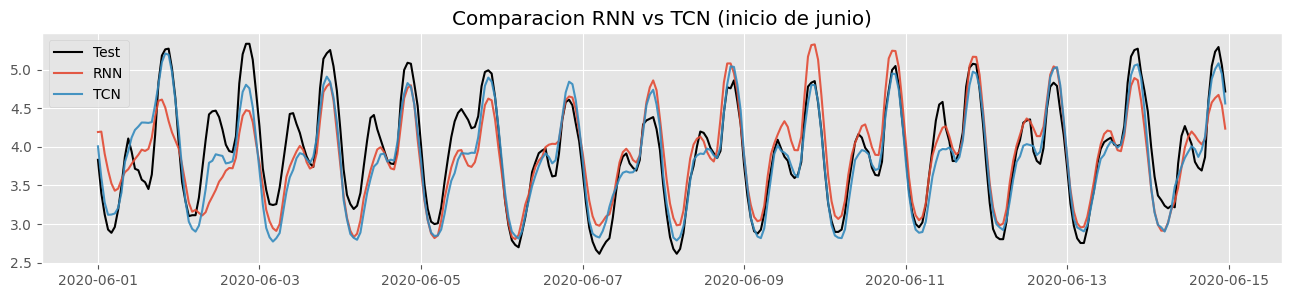

In [129]:
plt.figure(figsize=(16, 3))
plt.plot(june_test.index[:24 * 14], june_test["value"].values[:24 * 14], label="Test", color="black")
plt.plot(pred_rnn_june.index[:24 * 14], pred_rnn_june["RNN"].values[:24 * 14], label="RNN", alpha=0.9)
plt.plot(pred_tcn_june.index[:24 * 14], pred_tcn_june["TCN"].values[:24 * 14], label="TCN", alpha=0.9)
plt.title("Comparacion RNN vs TCN (inicio de junio)")
plt.legend(loc="best")
plt.show()

In [130]:
# Comparación global para el problema de forecasting de 1 semana.

pd.DataFrame([
    {"modelo": "RF_1w", "MAE": metrics_rf_1w["MAE"], "MAPE": metrics_rf_1w["MAPE"], "MSE": metrics_rf_1w["MSE"], "train_time": rf_1w_train_time},
    {"modelo": "XGB_1w", "MAE": metrics_xgb_1w["MAE"], "MAPE": metrics_xgb_1w["MAPE"], "MSE": metrics_xgb_1w["MSE"], "train_time": xgb_1w_train_time},
    {"modelo": "RNN_1w", "MAE": metrics_rnn_1w["MAE"], "MAPE": metrics_rnn_1w["MAPE"], "MSE": metrics_rnn_1w["MSE"], "train_time": rnn_train_time},
    {"modelo": "TCN_1w", "MAE": metrics_tcn_1w["MAE"], "MAPE": metrics_tcn_1w["MAPE"], "MSE": metrics_tcn_1w["MSE"], "train_time": tcn_train_time},
])

,modelo,MAE,MAPE,MSE,train_time
0,RF_1w,0.359027,0.089785,0.202092,34.653310
1,XGB_1w,0.348713,0.089293,0.197609,28.287079
2,RNN_1w,0.328336,0.087038,0.157503,100.219396
3,TCN_1w,0.302080,0.079454,0.142710,53.904995


### DISCUTIR:
1. Que diferencias se observan entre los resultados de RNN y TCN?
2. Discuta los resultados globales de todos los modelos. ¿Cuál es el mejor modelo? ¿Por qué?

1. Se puede ver que el modelo TCN obtiene mejores resultados que RNN, de todas manera esto puede ser una casualidad, ya que no se buscaron los mejores hiperparámetros. Pero lo que si es interesante de ver son los tiempos de entrenamiento, donde como se esperaba el modelo TCN es mucho más rápido por tener una arquitectura basada en convoluciones que se pueden paralelizar, en vez de cáluclos secuenciales como en el caso de RNN. Esto es un ejemplo de como la arquitectura de un modelo puede impactar en el tiempo de entrenamiento y en los resultados finales.

2. Para los modelos de la tabla de arriba, se puede ver que TCN además de tener una mejor performances, tiene tiempos de entrenamiento comparables con XGB, y mucho más chicos que RNN. Por otro lado, con RF los tiempos son significativamente mas chicos, pero si bien la performance es la peor, comparado con el resto las diferencia no son tan grandes. El mejor modelo va a depender de la situación y el costo que tenga por un lado cada punto porcentual de la performance, o el costo del tiempo de entrenamiento.

### EXPERIMENTAR:
1. Verificar que el largo de la secuencia de entrada no varía la cantidad de parámetros de los modelos de RNN y TCN.
2. Probar diferentes configuraciones de hiperparámetros para RNN y TCN, y discutir como cambian los resultados y el tiempo de entrenamiento.

In [131]:
# Modelo entrenado con una ventana de 1 mes de datos.

#TODO
H = 168
INPUT_SIZE = 4 * 168

tcn_model_1m = TCN(
    h=H,
    input_size=INPUT_SIZE,
    scaler_type="standard",
    loss=MSE(),
    valid_loss=MSE(),
    kernel_size=2,
    dilations=[1, 2, 4],
    encoder_hidden_size=32,
    max_steps=500,
    
)

fcst_tcn_1m = NeuralForecast(models=[tcn_model_1m], freq="h")

Seed set to 1


In [132]:
t0 = time.perf_counter()
fcst_tcn_1m.fit(df=dta_nf_train, val_size=720 * 3)
tcn_1m_train_time = time.perf_counter() - t0

print(f"Tiempo entrenamiento TCN: {tcn_1m_train_time:.2f}s")

print("Parametros entrenables TCN:", count_parameters(fcst_tcn_1m.models[0]))

GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name                | Type                       | Params | Mode 
---------------------------------------------------------------------------
0 | loss                | MSE                        | 0      | train
1 | valid_loss          | MSE                        | 0      | train
2 | hist_cat_embeddings | ModuleList                 | 0      | train
3 | futr_cat_embeddings | ModuleList                 | 0      | train
4 | stat_cat_embeddings | ModuleList                 | 0      | train
5 | padder_train        | ConstantPad1d              | 0      | train
6 | scaler              | TemporalNorm               | 0      | train
7 | hist_encoder        | TemporalConvolutionEncoder | 4.3 K  | train
8 | context_adapter     | Linear                     | 113 K  | train
9 | mlp_decoder         | MLP                        | 4.4 K  | train
---------------------------------------------------------------------------
12

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=500` reached.


Tiempo entrenamiento TCN: 84.19s
Parametros entrenables TCN: 121673


In [133]:
pred_tcn_1m_june = rolling_weekly_predict(fcst_tcn_1m, dta, "TCN", h=H, input_size=INPUT_SIZE)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

In [134]:
idx_tcn_1m = june_test.index.intersection(pred_tcn_june.index)
metrics_tcn_1m = metricas(june_test.loc[idx_tcn_1m, "value"].values, pred_tcn_1m_june.loc[idx_tcn_1m, "TCN"].values)
metrics_tcn_1m

{'MAE': 0.30735533835277673,
 'MSE': 0.14426967919801534,
 'MAPE': 0.08123299080499442}

COMENTARIOS:

Se puede ver que en el caso de TCN la cantidad de parámetros entrenables de la parte de codificación (TemporalConvolutionEncoder) no cambia por lo que se ve que no depende del largo de secuencia. 

In [135]:
# Se complejiza el modelo agregado más capas de convolución

#TODO
H = 168
INPUT_SIZE = 4 * 168

tcn_model_ext = TCN(
    h=H,
    input_size=INPUT_SIZE,
    scaler_type="standard",
    loss=MSE(),
    valid_loss=MSE(),
    kernel_size=2,
    dilations=[1, 2, 4, 8, 16, 32, 64, 128], # por cada dilatación se agrega una capa de convolución
    encoder_hidden_size=32,
    max_steps=500,
    
)

fcst_tcn_ext = NeuralForecast(models=[tcn_model_ext], freq="h")

Seed set to 1


In [136]:
t0 = time.perf_counter()
fcst_tcn_ext.fit(df=dta_nf_train, val_size=720 * 3)
tcn_ext_train_time = time.perf_counter() - t0

print(f"Tiempo entrenamiento TCN: {tcn_ext_train_time:.2f}s")

print("Parametros entrenables TCN:", count_parameters(fcst_tcn_1m.models[0]))

GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name                | Type                       | Params | Mode 
---------------------------------------------------------------------------
0 | loss                | MSE                        | 0      | train
1 | valid_loss          | MSE                        | 0      | train
2 | hist_cat_embeddings | ModuleList                 | 0      | train
3 | futr_cat_embeddings | ModuleList                 | 0      | train
4 | stat_cat_embeddings | ModuleList                 | 0      | train
5 | padder_train        | ConstantPad1d              | 0      | train
6 | scaler              | TemporalNorm               | 0      | train
7 | hist_encoder        | TemporalConvolutionEncoder | 14.7 K | train
8 | context_adapter     | Linear                     | 113 K  | train
9 | mlp_decoder         | MLP                        | 4.4 K  | train
---------------------------------------------------------------------------
13

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=500` reached.


Tiempo entrenamiento TCN: 133.59s
Parametros entrenables TCN: 121673


In [137]:
pred_tcn_ext_june = rolling_weekly_predict(fcst_tcn_ext, dta, "TCN", h=H, input_size=INPUT_SIZE)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

In [138]:
idx_tcn_ext = june_test.index.intersection(pred_tcn_ext_june.index)
metrics_tcn_ext = metricas(june_test.loc[idx_tcn_ext, "value"].values, pred_tcn_ext_june.loc[idx_tcn_ext, "TCN"].values)
metrics_tcn_ext

{'MAE': 0.3276999368376675,
 'MSE': 0.15908219117518735,
 'MAPE': 0.08481866173579596}